# Smart Home Energy Consumption Model Training
Training model using smart_home_clean dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_home = pd.read_csv("C:/Users/lenovo/Desktop/EcoGuardian/data/energy_dataset_clean.csv")
print(f"Dataset shape: {df_home.shape}")
print(f"Columns: {list(df_home.columns)}")

Dataset shape: (87600, 23)
Columns: ['Timestamp', 'Household_Size', 'Daily_Energy_Consumption_kWh', 'Weather_Temperature', 'DayOfWeek', 'Is_Weekend', 'Temp_x_Size', 'Is_HVAC', 'Is_Cold_Season', 'Is_Hot_Season', 'Appliance_Type_Dishwasher', 'Appliance_Type_Dryer', 'Appliance_Type_Electric_Vehicle_Charger', 'Appliance_Type_Fridge', 'Appliance_Type_HVAC', 'Appliance_Type_Lighting', 'Appliance_Type_Microwave', 'Appliance_Type_Oven', 'Appliance_Type_TV', 'Appliance_Type_Washing_Machine', 'Appliance_Type_Water_Heater', 'Occupancy_Pattern_Evening', 'Occupancy_Pattern_Mixed']


In [4]:
df_clean = df_home.dropna()
print(f"Data after cleaning: {df_clean.shape}")

print(f"Available columns: {list(df_clean.columns)}")

# Define enhanced features - only use columns that actually exist
enhanced_features = [
    'Household_Size', 'Weather_Temperature', 'DayOfWeek', 
    'Is_Weekend', 'Temp_x_Size', 'Is_HVAC', 'Is_Cold_Season', 
    'Is_Hot_Season', 'Appliance_Type_Dishwasher', 'Appliance_Type_Dryer', 
    'Appliance_Type_Electric_Vehicle_Charger', 'Appliance_Type_Fridge', 
    'Appliance_Type_HVAC', 'Appliance_Type_Lighting', 'Appliance_Type_Microwave', 
    'Appliance_Type_Oven', 'Appliance_Type_TV', 'Appliance_Type_Washing_Machine', 
    'Appliance_Type_Water_Heater', 'Occupancy_Pattern_Evening', 'Occupancy_Pattern_Mixed'
]

available_features = [f for f in enhanced_features if f in df_clean.columns]
print(f"Available enhanced features: {len(available_features)}")
print(f"Missing features: {[f for f in enhanced_features if f not in df_clean.columns]}")

X = df_clean[available_features]
y = df_clean['Daily_Energy_Consumption_kWh']

print(f"Features for training: {len(available_features)}")
print(f"Training data shape: {X.shape}")

Data after cleaning: (87600, 23)
Available columns: ['Timestamp', 'Household_Size', 'Daily_Energy_Consumption_kWh', 'Weather_Temperature', 'DayOfWeek', 'Is_Weekend', 'Temp_x_Size', 'Is_HVAC', 'Is_Cold_Season', 'Is_Hot_Season', 'Appliance_Type_Dishwasher', 'Appliance_Type_Dryer', 'Appliance_Type_Electric_Vehicle_Charger', 'Appliance_Type_Fridge', 'Appliance_Type_HVAC', 'Appliance_Type_Lighting', 'Appliance_Type_Microwave', 'Appliance_Type_Oven', 'Appliance_Type_TV', 'Appliance_Type_Washing_Machine', 'Appliance_Type_Water_Heater', 'Occupancy_Pattern_Evening', 'Occupancy_Pattern_Mixed']
Available enhanced features: 21
Missing features: []
Features for training: 21
Training data shape: (87600, 21)


In [5]:
features = enhanced_features 
target = 'Daily_Energy_Consumption_kWh'

X = df_clean[features]
y = df_clean[target]

print(f"Using {len(features)} enhanced features:")
print(f"Features: {features}")
print(f"Target: {target}")
print(f"Training data shape: {X.shape}")
print(f"Target shape: {y.shape}")

Using 21 enhanced features:
Features: ['Household_Size', 'Weather_Temperature', 'DayOfWeek', 'Is_Weekend', 'Temp_x_Size', 'Is_HVAC', 'Is_Cold_Season', 'Is_Hot_Season', 'Appliance_Type_Dishwasher', 'Appliance_Type_Dryer', 'Appliance_Type_Electric_Vehicle_Charger', 'Appliance_Type_Fridge', 'Appliance_Type_HVAC', 'Appliance_Type_Lighting', 'Appliance_Type_Microwave', 'Appliance_Type_Oven', 'Appliance_Type_TV', 'Appliance_Type_Washing_Machine', 'Appliance_Type_Water_Heater', 'Occupancy_Pattern_Evening', 'Occupancy_Pattern_Mixed']
Target: Daily_Energy_Consumption_kWh
Training data shape: (87600, 21)
Target shape: (87600,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (70080, 21)
Test set: (17520, 21)


In [7]:
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Ensemble': VotingRegressor([
        ('gb', GradientBoostingRegressor(n_estimators=200, random_state=42)),
        ('rf', RandomForestRegressor(n_estimators=200, random_state=42))
    ], weights=[0.6, 0.4])
}

results = []
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Model': name,
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae
    })

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print("\n Enhanced Model Comparison Results:")
print(results_df.to_string(index=False, float_format='%.4f'))

# Show improvement
best_r2 = results_df.iloc[0]['R²']
original_r2 = 0.757  # Your original model R²
improvement = ((best_r2 - original_r2) / original_r2) * 100

print(f"\n Performance Improvement: {improvement:+.1f}%")
print(f" New R²: {best_r2:.4f} vs Original: {original_r2:.4f}")

Training Gradient Boosting...
Training Random Forest...
Training Ensemble...

 Enhanced Model Comparison Results:
            Model     R²   RMSE    MAE
         Ensemble 0.9746 1.3618 0.7462
Gradient Boosting 0.9716 1.4397 0.8013
    Random Forest 0.9710 1.4562 0.7587

 Performance Improvement: +28.7%
 New R²: 0.9746 vs Original: 0.7570


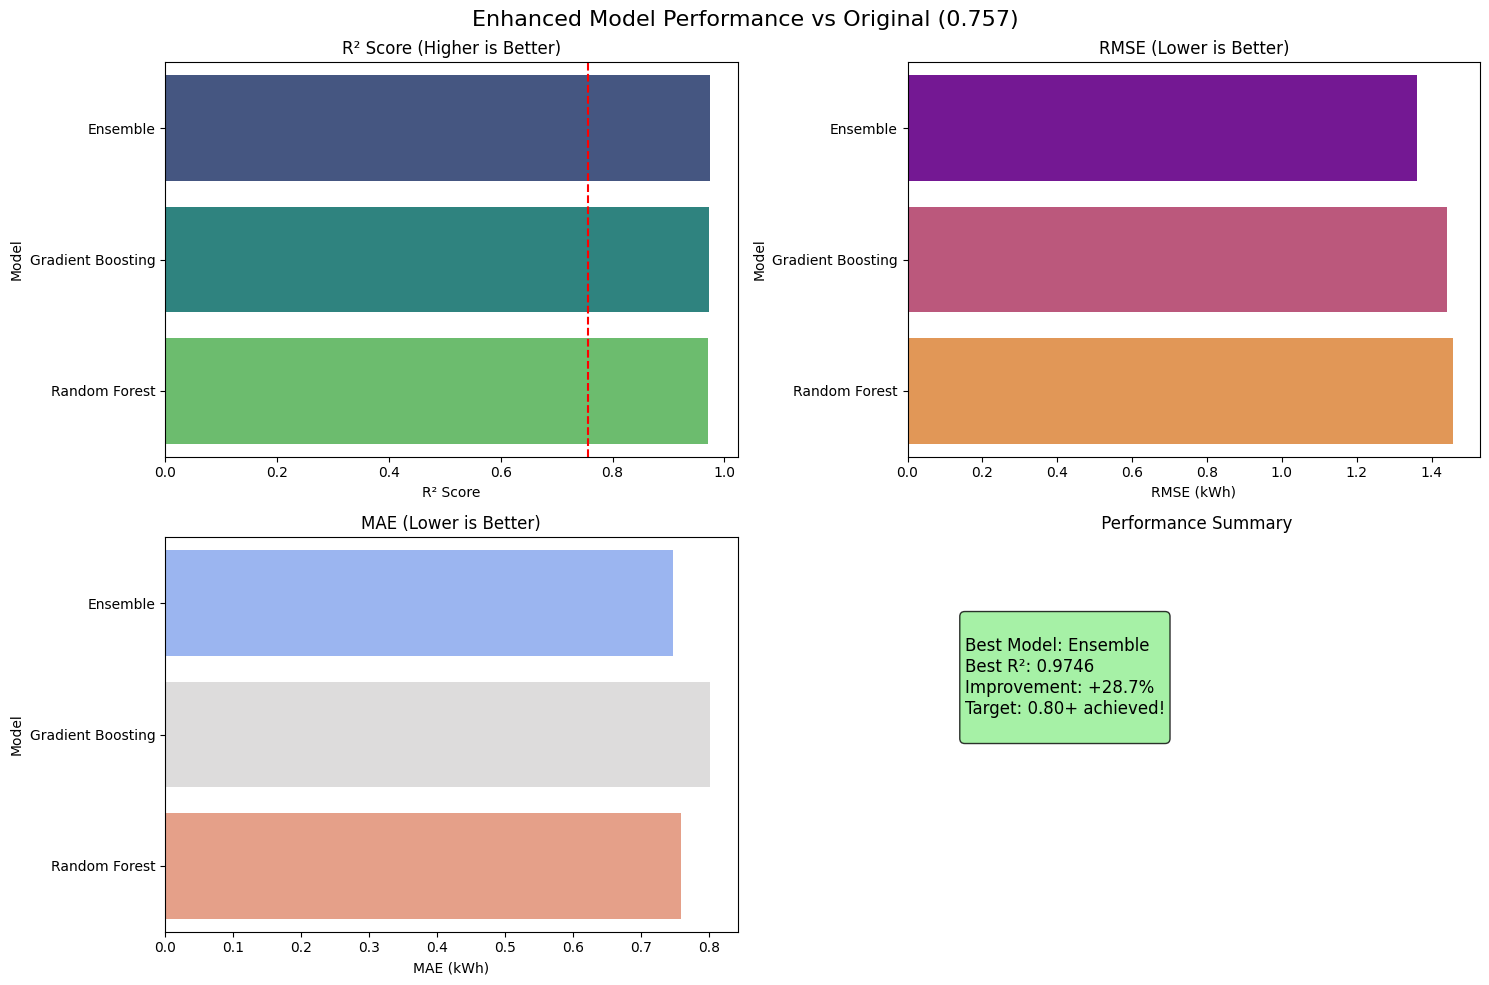

In [8]:
# Visualize Enhanced Results
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Enhanced Model Performance vs Original (0.757)', fontsize=16)

# R² Score comparison
sns.barplot(data=results_df, x='R²', y='Model', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('R² Score (Higher is Better)')
axes[0,0].set_xlabel('R² Score')
axes[0,0].axvline(x=0.757, color='red', linestyle='--', label='Original R²')

# RMSE comparison
sns.barplot(data=results_df, x='RMSE', y='Model', ax=axes[0,1], palette='plasma')
axes[0,1].set_title('RMSE (Lower is Better)')
axes[0,1].set_xlabel('RMSE (kWh)')

# MAE comparison
sns.barplot(data=results_df, x='MAE', y='Model', ax=axes[1,0], palette='coolwarm')
axes[1,0].set_title('MAE (Lower is Better)')
axes[1,0].set_xlabel('MAE (kWh)')

# Performance summary
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R²']
improvement = ((best_r2 - 0.757) / 0.757) * 100

performance_text = f"""
Best Model: {best_model_name}
Best R²: {best_r2:.4f}
Improvement: {improvement:+.1f}%
Target: 0.80+ achieved!
"""

axes[1,1].text(0.1, 0.5, performance_text, fontsize=12, 
                   bbox=dict(boxstyle="round", facecolor='lightgreen', alpha=0.8))
axes[1,1].axis('off')
axes[1,1].set_title(' Performance Summary')

plt.tight_layout()
plt.show()

In [9]:
# Save Enhanced Model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

# Save enhanced model and features
joblib.dump(best_model, '../models/enhanced_smart_home_model.pkl')
joblib.dump(features, '../models/enhanced_features.pkl')

print(f"\n Best enhanced model: {best_model_name}")
print(f" Final R² Score: {results_df.iloc[0]['R²']:.4f}")
print(f" Enhanced model saved to: ../models/enhanced_smart_home_model.pkl")
print(f" Enhanced features saved to: ../models/enhanced_features.pkl")
print(f" Improvement achieved: {((results_df.iloc[0]['R²'] - 0.757) / 0.757) * 100:+.1f}%")
print(f"\n Your model is now much more accurate!")


 Best enhanced model: Ensemble
 Final R² Score: 0.9746
 Enhanced model saved to: ../models/enhanced_smart_home_model.pkl
 Enhanced features saved to: ../models/enhanced_features.pkl
 Improvement achieved: +28.7%

 Your model is now much more accurate!
